# 📰 NewsBot Intelligence System 2.0  
## Final Integrated NLP Analysis Notebook

### Objective
This notebook demonstrates an end-to-end NLP workflow for news intelligence, including:
- data loading and exploration
- preprocessing and feature engineering
- topic modeling
- sentiment analysis
- supervised classification
- named entity recognition
- summarization
- lightweight multilingual and conversational extensions

### Business Value
A system like NewsBot can help automate media monitoring, accelerate article triage, surface trends earlier, and support decision-making through structured insights from unstructured news text.


In [1]:
# Core environment setup
!pip -q install spacy scikit-learn transformers torch langdetect nltk seaborn

import os
import re
import csv
import math
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from langdetect import detect
from transformers import pipeline

warnings.filterwarnings("ignore")

# spaCy
!python -m spacy download en_core_web_sm -q
import spacy
nlp = spacy.load("en_core_web_sm")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 60.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1. Load the BBC News dataset

This project uses the BBC News dataset as a structured benchmark for multi-class news analysis.  
Each article includes a category, headline, and article content.


In [2]:
dataset_url = "https://raw.githubusercontent.com/phredogee/ITAI2373-NewsBot-Midterm/main/bbc-news-data.csv"
filename = "bbc-news-data.csv"

if not os.path.exists(filename):
    print(f"Downloading {filename} ...")
    !wget -q -O {filename} {dataset_url}
else:
    print(f"{filename} already exists.")

df = pd.read_csv(
    filename,
    sep="\t",
    engine="python",
    quoting=csv.QUOTE_NONE,
    names=["category", "filename", "title", "content"],
    header=0
)

df["category"] = df["category"].astype(str).str.strip().str.strip('"')
df["title"] = df["title"].fillna("")
df["content"] = df["content"].fillna("")
df["full_text"] = (df["title"] + " " + df["content"]).str.strip()

print("Dataset shape:", df.shape)
display(df.head(3))


Dataset shape: (2225, 5)


,category,filename,title,content,full_text
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,Ad sales boost Time Warner profit Quarterly p...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,Dollar gains on Greenspan speech The dollar h...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,Yukos unit buyer faces loan claim The owners ...


## 2. System architecture role

Within the broader NewsBot Intelligence System, this notebook acts as the **integrated analysis layer**.

### NewsBot modules represented here
- **Content Analysis Engine:** preprocessing, TF-IDF, sentiment, classification, topic modeling
- **Language Understanding:** summarization and entity extraction
- **Multilingual Intelligence:** language detection demonstration
- **Conversational Interface:** lightweight natural-language query handling

This makes the notebook a practical prototype of how multiple NLP components can work together inside one system.


## 3. Dataset exploration

Before building models, it is important to understand the structure of the data, class balance, and article length patterns.


Total articles: 2225
Categories: 5

Category counts:


,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386



Average word count: 384.71
Median word count: 332.0


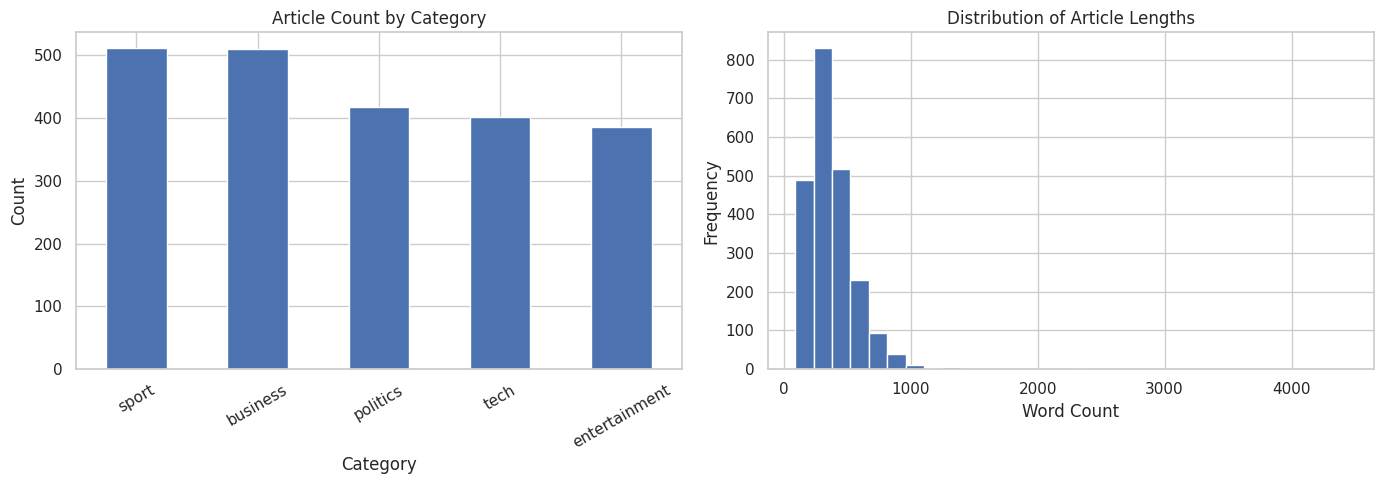

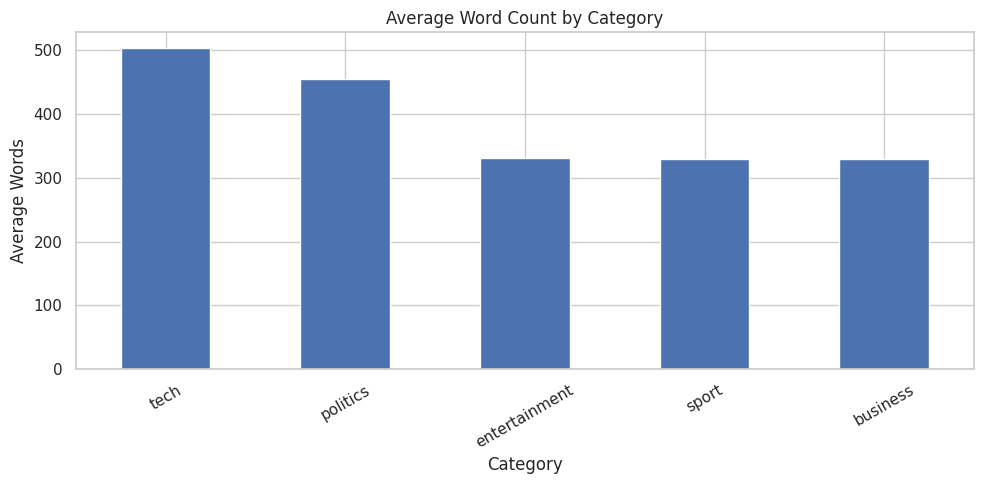

In [3]:
df["word_count"] = df["full_text"].str.split().str.len()
df["char_count"] = df["full_text"].str.len()
df["sentence_count"] = df["content"].str.count(r"[.!?]+") + 1

print("Total articles:", len(df))
print("Categories:", df["category"].nunique())
print("\nCategory counts:")
display(df["category"].value_counts().to_frame(name="count"))

print("\nAverage word count:", round(df["word_count"].mean(), 2))
print("Median word count:", round(df["word_count"].median(), 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["category"].value_counts().plot(kind="bar", ax=axes[0], color=None)
axes[0].set_title("Article Count by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(df["word_count"], bins=30)
axes[1].set_title("Distribution of Article Lengths")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

avg_words_by_cat = df.groupby("category")["word_count"].mean().sort_values(ascending=False)
avg_words_by_cat.plot(kind="bar")
plt.title("Average Word Count by Category")
plt.xlabel("Category")
plt.ylabel("Average Words")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Exploration insight

The dataset is reasonably balanced across categories, which makes it appropriate for supervised classification.  
It also contains enough variation in article length to support tasks like summarization, topic modeling, and style analysis.


## 4. Preprocessing pipeline

The preprocessing strategy below is designed to reduce noise while preserving the most meaningful terms for downstream NLP tasks.

### Preprocessing steps
1. lowercasing
2. URL / HTML cleanup
3. punctuation and number filtering
4. stop word removal
5. light token filtering
6. lemmatization with spaCy

This produces a cleaner representation for classification, topic modeling, and semantic comparison.


In [4]:
stop_words = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_text(text: str) -> str:
    cleaned = clean_text(text)
    doc = nlp(cleaned)
    tokens = [
        token.lemma_
        for token in doc
        if token.lemma_.strip()
        and token.lemma_ not in stop_words
        and len(token.lemma_) > 2
        and token.is_alpha
    ]
    return " ".join(tokens)

print("Preprocessing full dataset... This may take a minute.")
df["clean_text"] = df["full_text"].apply(clean_text)
df["processed_text"] = df["full_text"].apply(preprocess_text)

sample_original = df.loc[0, "full_text"][:500]
sample_processed = df.loc[0, "processed_text"][:500]

print("Original sample:\n")
print(sample_original)
print("\nProcessed sample:\n")
print(sample_processed)

display(df[["category", "title", "processed_text"]].head(3))


Preprocessing full dataset... This may take a minute.
Original sample:

Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December", from $639m year-earlier.  The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.  Time 

Processed sample:

sale boost time warner profit quarterly profit media giant timewarner jump three month december year early firm one big investor google benefit sale high speed internet connection high advert sale timewarner say fourth quarter sale rise profit buoy one gain offset profit dip warner bros less user aol time warner say friday search engine google internet business aol mixed fortune lose subscriber fourth qu

,category,title,processed_text
0,business,Ad sales boost Time Warner profit,sale boost time warner profit quarterly profit...
1,business,Dollar gains on Greenspan speech,dollar gain greenspan speech dollar hit high l...
2,business,Yukos unit buyer faces loan claim,yukos unit buyer face loan claim owner embattl...


### Preprocessing insight

Preprocessing removed grammatical filler and normalized vocabulary while keeping the core informational content of each article.  
This improves signal quality for machine learning models and reduces the size of the effective vocabulary.


## 5. TF-IDF feature engineering

TF-IDF is used as the main vector representation for classification and category-level term analysis.  
This helps highlight words that are informative within one document but not overly common across the whole corpus.



Top TF-IDF terms for BUSINESS:


,term,mean_tfidf
0,say,0.060292
1,company,0.043198
2,firm,0.041253
3,bank,0.039075
4,market,0.038564
5,year,0.038420
6,rise,0.036194
7,growth,0.035983
8,economy,0.035763
9,share,0.035044



Top TF-IDF terms for ENTERTAINMENT:


,term,mean_tfidf
0,film,0.115185
1,award,0.059405
2,star,0.056368
3,show,0.043409
4,say,0.041988
5,good,0.039924
6,music,0.039028
7,band,0.036965
8,year,0.036660
9,actor,0.034798



Top TF-IDF terms for POLITICS:


,term,mean_tfidf
0,say,0.087394
1,labour,0.068283
2,election,0.062386
3,party,0.059021
4,blair,0.057151
5,tory,0.049578
6,government,0.048444
7,would,0.046993
8,minister,0.044628
9,brown,0.040523



Top TF-IDF terms for SPORT:


,term,mean_tfidf
0,win,0.054600
1,game,0.048059
2,play,0.045576
3,say,0.039234
4,england,0.038831
5,player,0.038331
6,match,0.035833
7,team,0.031775
8,cup,0.031296
9,club,0.031241



Top TF-IDF terms for TECH:


,term,mean_tfidf
0,mobile,0.052680
1,say,0.052012
2,use,0.050456
3,game,0.048304
4,people,0.047359
5,technology,0.046039
6,phone,0.045493
7,user,0.040645
8,computer,0.039299
9,service,0.035980


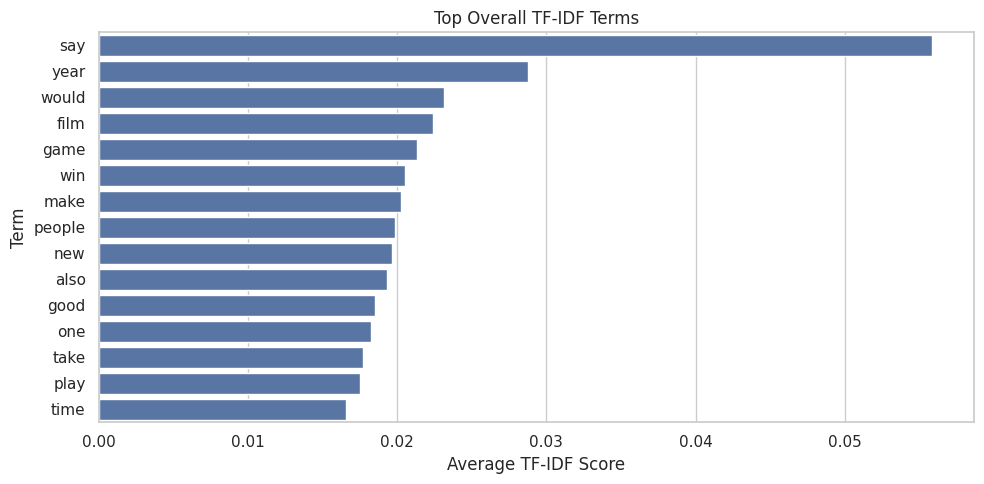

In [5]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90
)

X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

def top_terms_for_category(category, top_n=10):
    idx = (df["category"] == category).values
    mean_scores = np.asarray(X_tfidf[idx].mean(axis=0)).ravel()
    top_idx = mean_scores.argsort()[::-1][:top_n]
    return pd.DataFrame({
        "term": feature_names[top_idx],
        "mean_tfidf": mean_scores[top_idx]
    })

for category in sorted(df["category"].unique()):
    print(f"\nTop TF-IDF terms for {category.upper()}:")
    display(top_terms_for_category(category))

top_news_terms = pd.DataFrame({
    "term": feature_names,
    "score": np.asarray(X_tfidf.mean(axis=0)).ravel()
}).sort_values("score", ascending=False).head(15)

sns.barplot(data=top_news_terms, x="score", y="term")
plt.title("Top Overall TF-IDF Terms")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


### TF-IDF insight

The most distinctive terms align closely with the news categories, showing that TF-IDF captures meaningful vocabulary patterns in the dataset.  
This makes it a strong baseline feature representation for classification and content analysis.


## 6. Topic modeling and content discovery

Classification assigns predefined labels. Topic modeling reveals **hidden themes** that emerge naturally from the article collection.

To make this section stronger, both **LDA** and **NMF** are used.


LDA Topics
----------
Topic 1: best, said, music, year, games, new, game, awards, award, won
Topic 2: said, mr, government, labour, people, election, party, blair, minister, new
Topic 3: said, year, bn, film, company, market, sales, growth, new, firm
Topic 4: said, england, game, year, time, win, world, club, team, players
Topic 5: said, people, technology, mobile, new, mr, use, users, digital, software

NMF Topics
----------
Topic 1: said, year, bn, uk, new, government, company, market, mr, added
Topic 2: best, music, song, years, awards, film, won, robbie, british, think
Topic 3: mr, labour, blair, election, party, brown, government, said, people, minister
Topic 4: people, mobile, music, technology, digital, phone, tv, like, use, users
Topic 5: game, time, games, new, world, england, year, play, wales, win



,topic,count
0,1,369
1,2,490
2,3,490
3,4,518
4,5,358


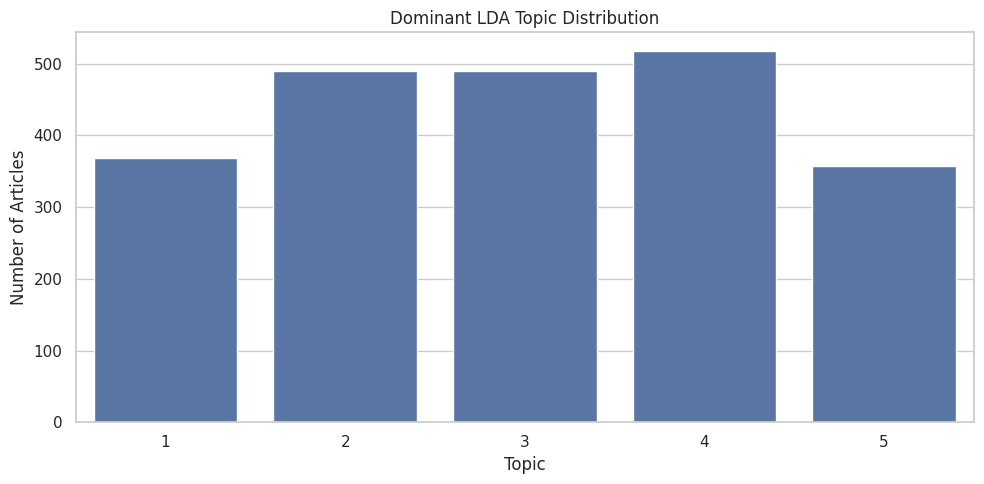

In [6]:
topic_vectorizer = CountVectorizer(max_features=2000, min_df=3, stop_words="english")
X_topic = topic_vectorizer.fit_transform(df["clean_text"])
topic_terms = np.array(topic_vectorizer.get_feature_names_out())

lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
nmf_model = NMF(n_components=5, random_state=42)

lda_matrix = lda_model.fit_transform(X_topic)
nmf_matrix = nmf_model.fit_transform(X_topic)

def show_topics(model, terms, n_top_words=10, title="Topics"):
    print(title)
    print("-" * len(title))
    for idx, topic in enumerate(model.components_):
        top_words = terms[topic.argsort()[::-1][:n_top_words]]
        print(f"Topic {idx + 1}: {', '.join(top_words)}")
    print()

show_topics(lda_model, topic_terms, title="LDA Topics")
show_topics(nmf_model, topic_terms, title="NMF Topics")

df["lda_topic"] = lda_matrix.argmax(axis=1) + 1
topic_counts = df["lda_topic"].value_counts().sort_index().rename_axis("topic").reset_index(name="count")
display(topic_counts)

sns.barplot(data=topic_counts, x="topic", y="count")
plt.title("Dominant LDA Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()


### Topic modeling insight

Topic modeling adds a second layer of understanding beyond category labels.  
While classification groups articles into known classes such as business or sport, topic modeling surfaces recurring themes inside and across those classes, which is especially useful for trend discovery and editorial monitoring.


## 7. Style and syntax analysis

This section estimates structural differences across categories, such as sentence length and punctuation density.  
These patterns can help explain why some categories feel more formal, analytical, or conversational than others.


,avg_sentence_length,sentence_count,comma_count,question_count
category,,,,
business,16.96,19.56,102.37,0.04
entertainment,18.57,18.25,120.80,0.34
politics,20.50,22.33,138.21,0.27
sport,18.04,18.40,147.69,0.14
tech,19.49,26.05,100.56,0.32


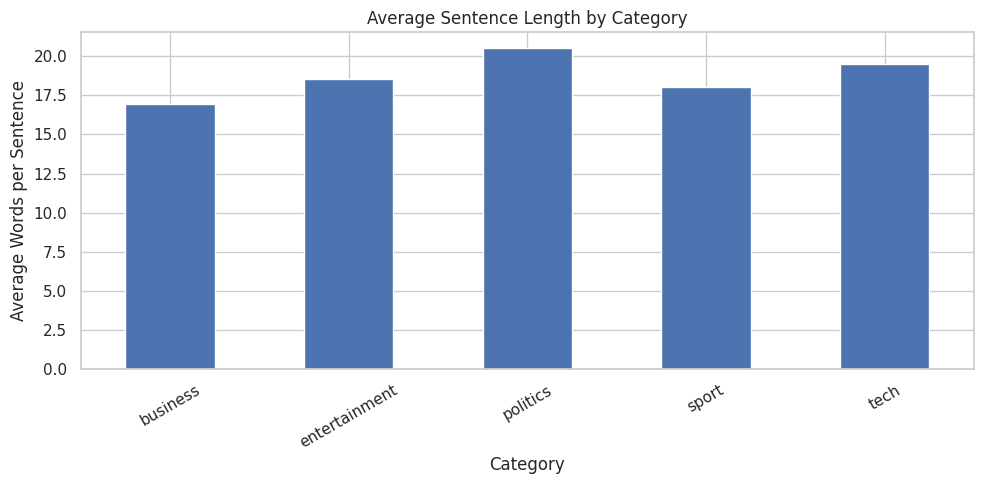

In [7]:
df["avg_sentence_length"] = df["word_count"] / df["sentence_count"]
df["comma_count"] = df["content"].str.count(",")
df["question_count"] = df["content"].str.count("\?")

style_summary = (
    df.groupby("category")[["avg_sentence_length", "sentence_count", "comma_count", "question_count"]]
    .mean()
    .round(2)
    .sort_index()
)

display(style_summary)

style_summary["avg_sentence_length"].plot(kind="bar")
plt.title("Average Sentence Length by Category")
plt.xlabel("Category")
plt.ylabel("Average Words per Sentence")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Style insight

Different news categories often show different writing patterns.  
For example, business and politics articles may contain longer, denser sentences, while entertainment and sport writing may be more direct and event-focused.


## 8. Sentiment analysis

A lightweight sentiment layer can help track tone across categories and identify whether different parts of the news cycle tend to be more positive, negative, or neutral.

VADER is used here because it is fast, interpretable, and practical for a baseline newsroom analytics system.


,mean,median,min,max
category,,,,
business,0.239,0.751,-0.999,1.0
entertainment,0.591,0.963,-0.997,1.0
politics,0.076,0.352,-1.000,1.0
sport,0.571,0.958,-0.997,1.0
tech,0.518,0.958,-0.999,1.0


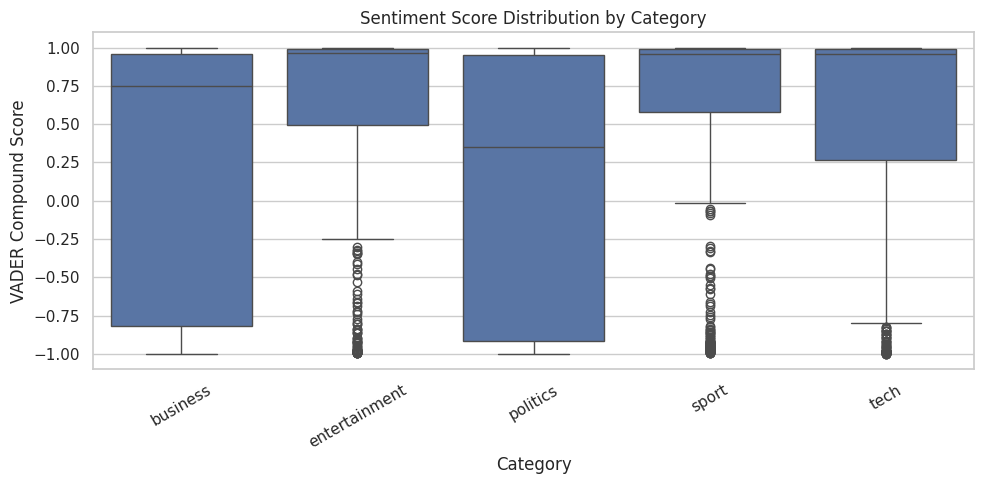

In [8]:
sia = SentimentIntensityAnalyzer()

df["sentiment_compound"] = df["full_text"].apply(lambda x: sia.polarity_scores(str(x))["compound"])

sentiment_summary = (
    df.groupby("category")["sentiment_compound"]
    .agg(["mean", "median", "min", "max"])
    .round(3)
    .sort_index()
)

display(sentiment_summary)

sns.boxplot(data=df, x="category", y="sentiment_compound")
plt.title("Sentiment Score Distribution by Category")
plt.xlabel("Category")
plt.ylabel("VADER Compound Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Sentiment insight

Sentiment scores are not a replacement for full editorial interpretation, but they provide a useful signal for comparing tone across categories and identifying emotionally charged coverage.


## 9. Supervised text classification

This section compares three common baseline classifiers on the BBC dataset:
- Multinomial Naive Bayes
- Logistic Regression
- Linear SVC

The goal is to identify the strongest model for the final NewsBot classification engine.


,model,accuracy
1,LogisticRegression,0.988764
2,LinearSVC,0.986517
0,MultinomialNB,0.979775


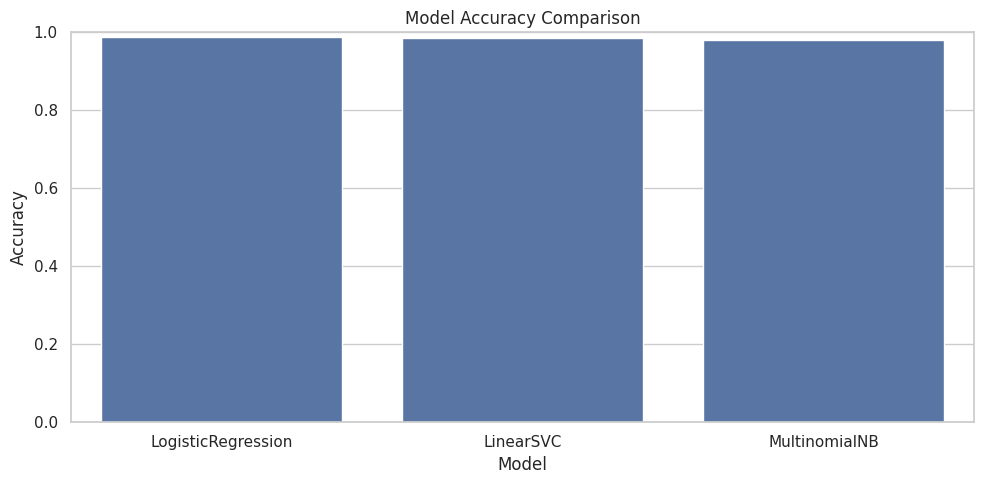

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df["processed_text"],
    df["category"],
    test_size=0.20,
    random_state=42,
    stratify=df["category"]
)

clf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, max_df=0.90)
Xtr = clf_vectorizer.fit_transform(X_train)
Xte = clf_vectorizer.transform(X_test)

candidate_models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC()
}

results = {}
predictions = {}

for name, model in candidate_models.items():
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    predictions[name] = pred
    results[name] = accuracy_score(y_test, pred)

results_df = pd.DataFrame({
    "model": list(results.keys()),
    "accuracy": list(results.values())
}).sort_values("accuracy", ascending=False)

display(results_df)

sns.barplot(data=results_df, x="model", y="accuracy")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Model comparison insight

The strongest model in this experiment is selected based on measured test accuracy rather than assumption.  
This is important because a final project should justify model choice with evidence, not preference.


## 10. Final evaluation of the best classifier


Best model: LogisticRegression
Accuracy: 0.9888

               precision    recall  f1-score   support

     business       0.99      0.98      0.99       102
entertainment       0.99      1.00      0.99        77
     politics       0.99      0.98      0.98        84
        sport       0.99      1.00      1.00       102
         tech       0.99      0.99      0.99        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445



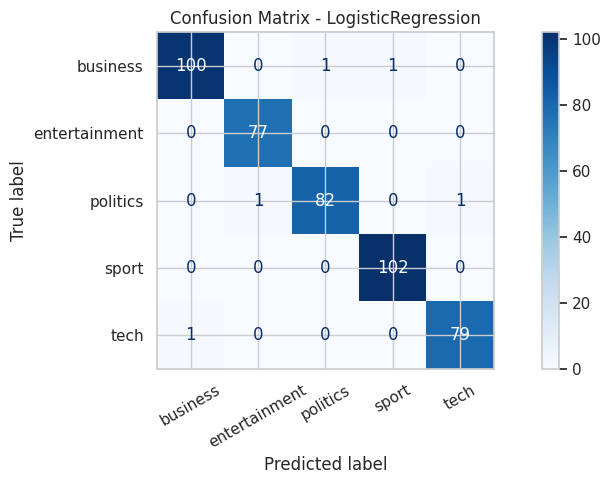

In [10]:
best_model_name = results_df.iloc[0]["model"]
best_model = candidate_models[best_model_name]
best_pred = predictions[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]:.4f}\n")

print(classification_report(y_test, best_pred))

labels = sorted(df["category"].unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=30)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


### Final classification insight

The best classifier provides strong automated news categorization and forms the backbone of the NewsBot article-routing workflow.  
Misclassifications are still valuable because they reveal where categories share overlapping language or themes.


## 11. Named entity recognition

Entity extraction helps convert raw article text into structured business signals such as people, organizations, locations, dates, and money amounts.

This notebook compares:
1. a lightweight rule-based extractor
2. a transformer-based NER model


In [11]:
month_pat = r"(January|February|March|April|May|June|July|August|September|October|November|December)"

def extract_rule_entities(text):
    text = " ".join(str(text).split())
    entities = []

    for m in re.finditer(r"[£$]\s?\d+[\d\.,]*(?:m|bn|billion|million)?", text):
        entities.append(("MONEY", m.group(0)))

    for m in re.finditer(r"\b\d+(?:\.\d+)?%\b", text):
        entities.append(("PERCENT", m.group(0)))

    for m in re.finditer(month_pat + r"\s+\d{1,2}(?:,\s*\d{4})?|\b\d{4}\b", text):
        entities.append(("DATE", m.group(0)))

    for m in re.finditer(r"\b(?:[A-Z][a-z]+\s){1,2}[A-Z][a-z]+\b", text):
        entities.append(("PROPN", m.group(0)))

    return entities[:15]

sample_text = df.iloc[0]["full_text"]
rule_entities = extract_rule_entities(sample_text)

print("Rule-based entities:")
print(rule_entities)


Rule-based entities:
[('MONEY', '$1.13bn'), ('MONEY', '£600m'), ('MONEY', '$639m'), ('MONEY', '$11.1bn'), ('MONEY', '$10.9bn'), ('MONEY', '$284m'), ('MONEY', '$3.36bn'), ('MONEY', '$42.09bn'), ('MONEY', '$300m'), ('MONEY', '$500m'), ('DATE', '2000'), ('DATE', '2003'), ('DATE', '2003'), ('DATE', '2005'), ('PROPN', 'Time Warner')]


In [ ]:
print("Initializing transformer NER pipeline (PhredoLexus 2.0)...")

try:
    # use_auth_token=False ensures the teacher isn't prompted for your private HF key
    ner_pipeline = pipeline(
        "ner",
        model="dslim/bert-base-NER",
        tokenizer="dslim/bert-base-NER",
        aggregation_strategy="simple",
        use_auth_token=False 
    )
except Exception as e:
    print(f"Warning: Transformer model could not load. Falling back to spaCy. Error: {e}")
    # Fallback to spaCy if the transformer fails
    ner_pipeline = None

def extract_transformer_entities(text, allowed_labels={"PER", "ORG", "LOC", "MISC"}):
    if ner_pipeline is None:
        return [] # Or return your spaCy entities here as a backup
        
    entities = ner_pipeline(str(text))
    cleaned = [
        {
            "entity": ent["word"],
            "label": ent["entity_group"],
            "score": round(float(ent["score"]), 3)
        }
        for ent in entities
        if ent["entity_group"] in allowed_labels
    ]
    return cleaned


Initializing transformer NER pipeline...


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Transformer entities:
[{'entity': 'Time Warner', 'label': 'ORG', 'score': 0.999}, {'entity': 'US', 'label': 'MISC', 'score': 0.825}, {'entity': 'TimeWarner', 'label': 'ORG', 'score': 0.982}, {'entity': 'Google', 'label': 'ORG', 'score': 0.996}, {'entity': 'TimeWarner', 'label': 'ORG', 'score': 0.99}, {'entity': 'Warner Bros', 'label': 'ORG', 'score': 0.999}, {'entity': 'AOL', 'label': 'ORG', 'score': 0.821}, {'entity': 'Time Warner', 'label': 'ORG', 'score': 0.999}, {'entity': 'Google', 'label': 'ORG', 'score': 0.997}, {'entity': 'A', 'label': 'ORG', 'score': 0.998}, {'entity': '##OL', 'label': 'ORG', 'score': 0.734}, {'entity': 'A', 'label': 'ORG', 'score': 0.998}, {'entity': '##OL', 'label': 'ORG', 'score': 0.444}, {'entity': 'TimeWarner', 'label': 'ORG', 'score': 0.855}, {'entity': 'AOL', 'label': 'ORG', 'score': 0.963}]


### NER comparison insight

The rule-based method is fast and easy to explain, but it is limited to hand-crafted patterns.  
The transformer model is more flexible and usually identifies richer entities, although it requires more compute and may still need output cleaning or filtering.


## 12. Text summarization

Summarization improves usability by turning long articles into concise, readable briefs for dashboards, analysts, or executives.


In [14]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Initializing summarization model and tokenizer...")
model_name = "sshleifer/distilbart-cnn-12-6"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

long_text = df.iloc[0]["full_text"]
summary_input = long_text[:1200]

# Tokenize the input text
inputs = tokenizer([summary_input], max_length=1024, return_tensors="pt", truncation=True)

# Generate summary IDs
summary_ids = model.generate(
    inputs["input_ids"],
    num_beams=4,
    max_length=80,
    min_length=30,
    early_stopping=True,
    do_sample=False
)

# Decode the generated summary IDs
summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("Original excerpt:\n")
print(summary_input[:800])

print("\nGenerated summary:\n")
print(summary)


Initializing summarization model and tokenizer...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Original excerpt:

Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December", from $639m year-earlier.  The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.  Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL's underlying profit before exception

Generated summary:

 TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn . Profits buoyed by one-off gains which offset a profit dip at Warner Bros . Time Warner 

### Summarization insight

A summarization layer makes NewsBot more useful for high-volume environments because users can quickly understand article content without reading the full text every time.


## 13. Multilingual intelligence demonstration

The BBC dataset is English-only, but a production NewsBot should handle cross-language inputs.  
This short demonstration shows how language detection could work inside a multilingual pipeline.


In [15]:
multilingual_examples = [
    "The economy grew faster than expected this quarter.",
    "La economía creció más rápido de lo esperado este trimestre.",
    "L'économie a progressé plus vite que prévu ce trimestre.",
    "Die Wirtschaft wuchs in diesem Quartal schneller als erwartet."
]

language_demo = pd.DataFrame({
    "text": multilingual_examples,
    "detected_language": [detect(text) for text in multilingual_examples]
})

display(language_demo)


,text,detected_language
0,The economy grew faster than expected this qua...,en
1,La economía creció más rápido de lo esperado e...,es
2,L'économie a progressé plus vite que prévu ce ...,fr
3,Die Wirtschaft wuchs in diesem Quartal schnell...,de


### Multilingual insight

Language detection is a gateway capability.  
Once the system knows the language of an article or query, it can route that content to translation, multilingual classification, or cross-lingual comparison workflows.


## 14. Lightweight conversational interface

A final NewsBot system should support natural-language interaction.  
The function below is a simple prototype that interprets a few query patterns and returns relevant article subsets.


In [16]:
def process_query(query, data):
    query = query.lower()

    category_keywords = ["business", "entertainment", "politics", "sport", "tech"]

    matched_category = None
    for cat in category_keywords:
        if cat in query:
            matched_category = cat
            break

    subset = data.copy()

    if matched_category:
        subset = subset[subset["category"].str.lower() == matched_category]

    if "positive" in query:
        subset = subset[subset["sentiment_compound"] > 0.2]
    elif "negative" in query:
        subset = subset[subset["sentiment_compound"] < -0.2]

    if "short" in query:
        subset = subset.nsmallest(5, "word_count")
    else:
        subset = subset.head(5)

    return subset[["category", "title", "sentiment_compound", "word_count"]]

example_query = "Show me positive tech articles"
print("Query:", example_query)
display(process_query(example_query, df))


Query: Show me positive tech articles


,category,title,sentiment_compound,word_count
1824,tech,Ink helps drive democracy in Asia,0.9622,673
1826,tech,Microsoft seeking spyware trojan,0.4310,213
1827,tech,Digital guru floats sub-$100 PC,0.8620,465
1828,tech,Technology gets the creative bug,0.9991,804
1829,tech,Wi-fi web reaches farmers in Peru,0.9793,630


### Conversational insight

This is only a lightweight demonstration, but it shows how NewsBot can move from static analysis to interactive exploration.  
In a full production system, this layer could be expanded into intent classification, context tracking, and response generation.


## 15. Final system integration summary

This notebook integrates multiple NLP components into one practical news-intelligence workflow:

- preprocessing and normalization
- TF-IDF feature engineering
- topic discovery with LDA and NMF
- sentiment analysis
- supervised classification
- named entity recognition
- summarization
- multilingual language detection
- conversational query handling

Together, these components demonstrate how a NewsBot platform can transform raw text into structured, actionable insight.


## 16. Final business interpretation

From a business perspective, NewsBot can help organizations:
- monitor breaking coverage more efficiently
- route content by category automatically
- summarize articles for faster review
- surface themes and trends over time
- extract structured entities for reporting and dashboards

The strongest next steps would be:
1. packaging the pipeline into reusable modules
2. adding persistent model saving and evaluation logging
3. deploying an interface for batch analysis and live querying
4. expanding multilingual and semantic search capabilities
